# Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding
**Student:** Manyok Gai  
**Course topic:** Uninformed Search and Problem Formulation  
**Algorithms:** BFS, DFS, DLS, IDS  
**Programming style:** Object-Oriented Python


# 1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# 2. The Abstract Problem Interface

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


# 3. The Node Class

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional['Node'] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


# 4. Helper Functions

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    return {
        'Algorithm': result.algorithm,
        'Status': result.status,
        'Limit': result.limit,
        'Solution depth': result.solution_depth,
        'Solution cost': result.solution_cost,
        'Nodes expanded': result.nodes_expanded,
        'Max frontier/stack': result.max_frontier_size,
        'Reached states': result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    return pd.DataFrame([result_to_row(r) for r in results])


# 5. GridProblem

In [5]:
MOVES = {
    'UP':    (-1,  0),
    'DOWN':  ( 1,  0),
    'LEFT':  ( 0, -1),
    'RIGHT': ( 0,  1),
}


class GridProblem(Problem):
    def __init__(self, grid: List[List[int]], start: Tuple[int,int], goal: Tuple[int,int]):
        self.grid  = grid
        self.start = start
        self.goal  = goal
        self.rows  = len(grid)
        self.cols  = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # returning True when the drone reaches the goal cell
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # collecting moves that land on a free cell inside the grid
        row, col = state
        legal_actions = []
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # applying the move delta to get the next position
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state: Tuple[int,int], action: str, next_state: Tuple[int,int]) -> float:
        # every move costs 1 on this grid
        return 1


## 5.1 Self-Check

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ['RIGHT']
assert test_problem.result((0, 0), 'RIGHT') == (0, 1)
assert test_problem.action_cost((0, 0), 'RIGHT', (0, 1)) == 1

print('GridProblem self-check passed.')


GridProblem self-check passed.


# 6. Sample Drone Map

In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start   = (0, 0)
goal    = (9, 9)
problem = GridProblem(sample_grid, start, goal)


# 7. Visualisation Helper

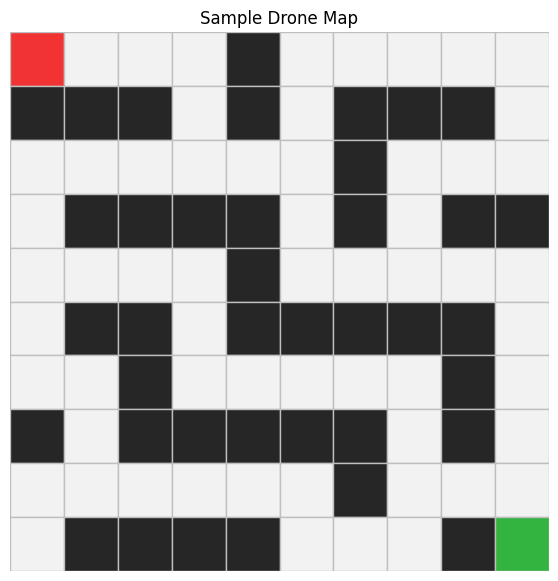

In [22]:
def plot_path(grid, start=None, goal=None, path=None, terrain_costs=None, title='Grid Map'):
    arr      = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)
            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)
            rect = patches.Rectangle(
                (col, row), 1, 1,
                linewidth=1, edgecolor=(0.75,0.75,0.75), facecolor=fill
            )
            ax.add_patch(rect)
    plt.show()


plot_path(sample_grid, start, goal, title='Sample Drone Map')


# 8. The Shared expand Method

In [9]:
class SearchAlgorithm(ABC):

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # getting the current state, asking for legal actions,
        # then yielding a child node for each one
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost    = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


# 9. Breadth-First Search (BFS)

In [10]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm      = 'BFS'
        nodes_expanded = 0
        max_frontier   = 0

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(algorithm, 'success', node, 0, 1, 1)

        # FIFO queue — nodes added at the back, removed from the front
        frontier = deque([node])
        reached  = {node.state}

        while frontier:
            max_frontier   = max(max_frontier, len(frontier))
            node           = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm, 'success', child,
                                        nodes_expanded, max_frontier, len(reached))
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

        return SearchResult(algorithm, 'failure', None,
                            nodes_expanded, max_frontier, len(reached))


# 10. Depth-First Search (DFS)

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm      = 'DFS'
        nodes_expanded = 0
        max_frontier   = 0

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(algorithm, 'success', node, 0, 1, 1)

        # LIFO stack, last in, first out so DFS goes deep first
        frontier = [node]
        reached  = {node.state}

        while frontier:
            max_frontier   = max(max_frontier, len(frontier))
            node           = frontier.pop()
            nodes_expanded += 1

            # reversing so actions are explored in MOVES order
            for child in reversed(list(self.expand(problem, node))):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm, 'success', child,
                                        nodes_expanded, max_frontier, len(reached))
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

        return SearchResult(algorithm, 'failure', None,
                            nodes_expanded, max_frontier, len(reached))


# 11. Depth-Limited Search (DLS)

In [12]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm    = 'DLS'
        initial_node = Node(problem.initial_state())
        metrics      = {'nodes_expanded': 0, 'max_stack_size': 1}

        solution, status = self._recursive_dls(
            problem, initial_node, limit, metrics, current_stack_size=1
        )

        return SearchResult(
            algorithm         = algorithm,
            status            = status,
            solution          = solution,
            nodes_expanded    = metrics['nodes_expanded'],
            max_frontier_size = metrics['max_stack_size'],
            reached_count     = 0,
            limit             = limit,
        )

    def _recursive_dls(self, problem, node, limit, metrics, current_stack_size):
        # found the goal
        if problem.is_goal(node.state):
            return (node, 'success')

        # reached the depth limit without finding the goal
        if node.depth >= limit:
            return (None, 'cutoff')

        metrics['nodes_expanded'] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            # skipping states already on this path to avoid cycles
            if state_is_on_path(node, child.state):
                continue

            metrics['max_stack_size'] = max(
                metrics['max_stack_size'], current_stack_size + 1
            )

            result, status = self._recursive_dls(
                problem, child, limit, metrics, current_stack_size + 1
            )

            if status == 'success':
                return (result, 'success')
            if status == 'cutoff':
                cutoff_occurred = True

        if cutoff_occurred:
            return (None, 'cutoff')
        return (None, 'failure')


# 12. Iterative Deepening Search (IDS)

In [13]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm            = 'IDS'
        iteration_log        = []
        total_nodes_expanded = 0
        overall_max_stack    = 0
        dls                  = DepthLimitedSearch()

        for limit in range(0, max_depth + 1):
            result = dls.search(problem, limit=limit)

            iteration_log.append({
                'limit': limit,
                'status': result.status,
                'nodes_expanded': result.nodes_expanded,
            })

            total_nodes_expanded += result.nodes_expanded
            overall_max_stack     = max(overall_max_stack, result.max_frontier_size)

            if result.status == 'success':
                return SearchResult(
                    algorithm='IDS', status='success',
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack,
                    reached_count=0, limit=limit,
                    iterations=iteration_log,
                )

            # no solution exists at any depth
            if result.status == 'failure':
                return SearchResult(
                    algorithm='IDS', status='failure',
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack,
                    reached_count=0, limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm='IDS', status='cutoff',
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_stack,
            reached_count=0, limit=max_depth,
            iterations=iteration_log,
        )


# 13. Run the Algorithms on the Sample Map

In [14]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),   # limit too small, expecting cutoff
    dls.search(problem, limit=25),   # limit large enough
    ids.search(problem, max_depth=30),
]

show_results(results)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,DLS,success,25.0,24.0,24.0,45,26,0
4,IDS,success,18.0,18.0,18.0,356,19,0


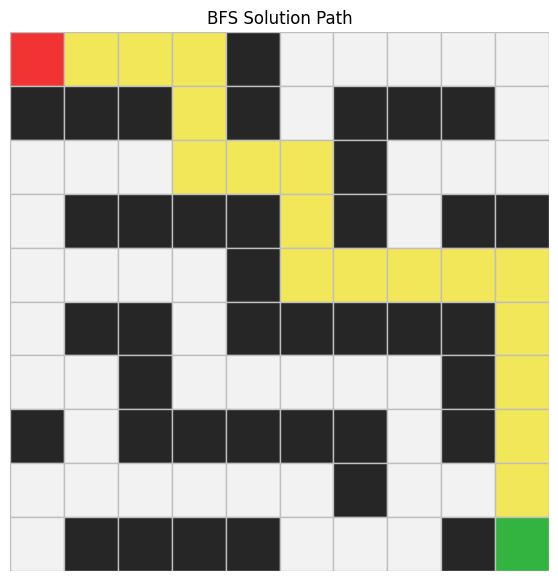

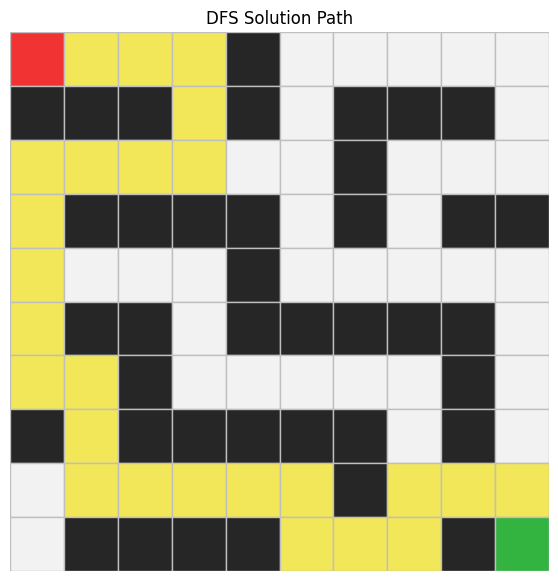

In [15]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(sample_grid, start, goal, path=bfs_result.path, title='BFS Solution Path')
plot_path(sample_grid, start, goal, path=dfs_result.path, title='DFS Solution Path')


# 14. Custom Maps

## Custom Map 1: Long Narrow Corridor (12x12)

This map forces the drone through a winding narrow passage.
DFS tends to explore dead-end branches before finding the goal.
BFS finds the shortest path reliably.


In [16]:
custom_grid_1 = [
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1   = (0, 0)
custom_goal_1    = (11, 11)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,38.0,38.0,68,7,73
1,DFS,success,NaN,38.0,38.0,84,10,87
2,DLS,cutoff,20.0,NaN,NaN,20,21,0
3,IDS,success,38.0,38.0,38.0,876,39,0


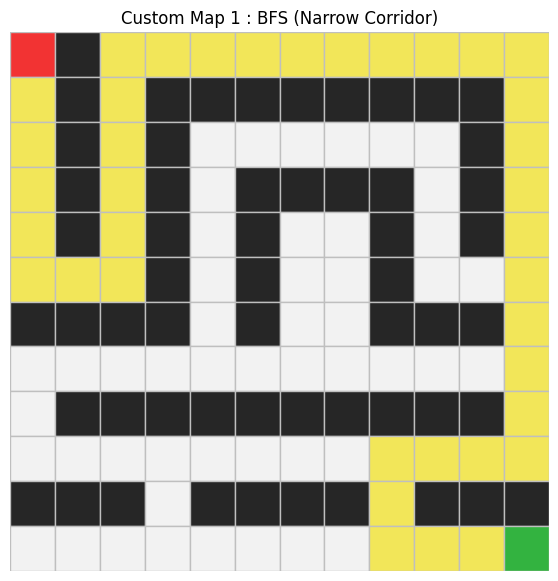

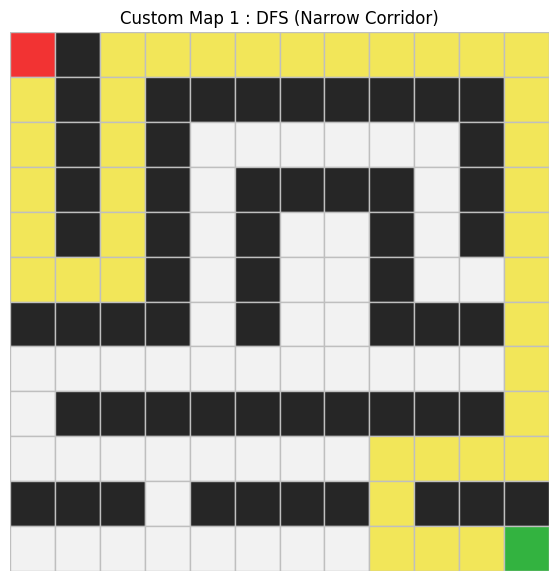

In [17]:
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[0].path, title='Custom Map 1 : BFS (Narrow Corridor)')
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path, title='Custom Map 1 : DFS (Narrow Corridor)')


## Custom Map 2: Many Dead Ends (15x15)

A larger map with many branching dead-end paths.
DFS enters many dead ends before finding the goal.
IDS should match BFS on solution depth while using less memory.


In [18]:
custom_grid_2 = [
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2   = (0, 0)
custom_goal_2    = (14, 14)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=30),
    ids.search(custom_problem_2, max_depth=50),
]

show_results(custom_results_2)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28,28,112,8,115
1,DFS,success,NaN,40,40,54,5,57
2,DLS,success,30.0,28,28,177,31,0
3,IDS,success,28.0,28,28,1336,29,0


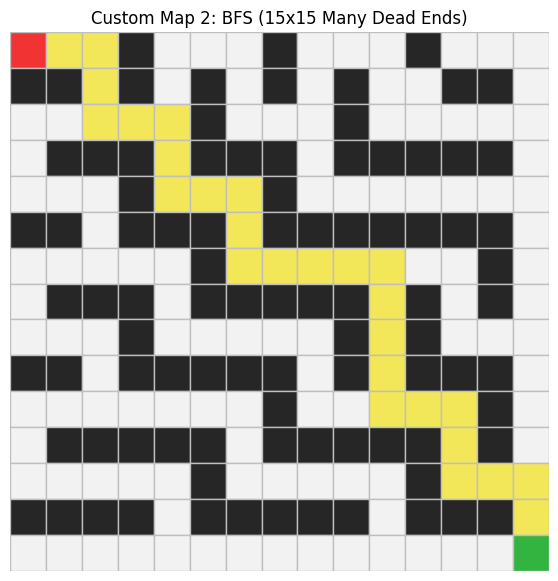

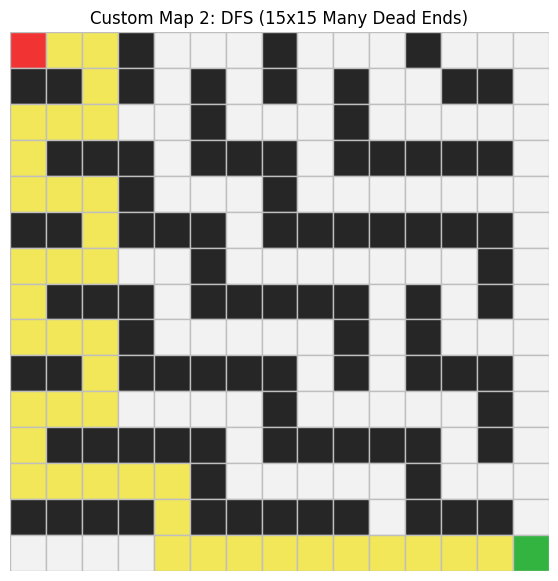

In [20]:
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[0].path, title='Custom Map 2: BFS (15x15 Many Dead Ends)')
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path, title='Custom Map 2: DFS (15x15 Many Dead Ends)')
